#Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.models as models
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import torch.nn.functional as F
import cv2
import random
from torch.utils.data import DataLoader
from google.colab import drive
import torchvision.transforms as T

In [2]:
# Check if CUDA is available
print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

True


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Dataset class names
class_names = ['DR', 'No DR']

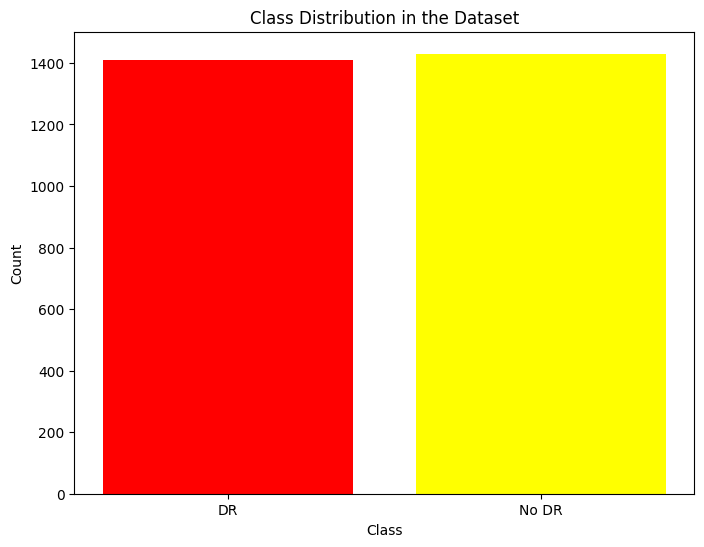

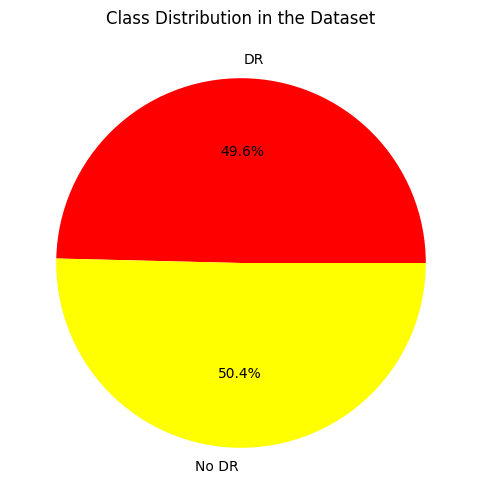

In [5]:
# Class names and their corresponding counts
class_counts = [1408, 1430] # Replace with actual counts

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(class_names, class_counts, color=['red', 'yellow'])
plt.title('Class Distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_names, autopct='%1.1f%%', colors=['red', 'yellow'])
plt.title('Class Distribution in the Dataset')
plt.show()

In [6]:
# Dataset paths
TRAIN_ROOT = "/content/drive/MyDrive/Diagnosis of Diabetic Retinopathy/Train"
TEST_ROOT = "/content/drive/MyDrive/Diagnosis of Diabetic Retinopathy/Test"

In [7]:
# Define data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
# Create datasets and dataloaders
train_dataset = torchvision.datasets.ImageFolder(root=TRAIN_ROOT, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=TEST_ROOT, transform=transform)

print("Number of images in training dataset:", len(train_dataset))
print("Number of images in testing dataset:", len(test_dataset))

Number of images in training dataset: 2270
Number of images in testing dataset: 568


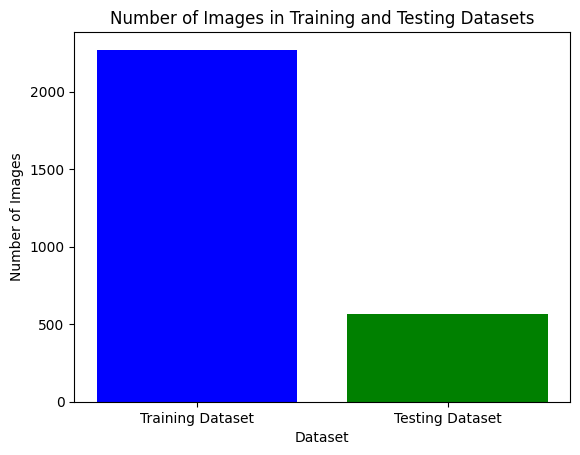

In [9]:
# Number of images in each dataset
training_images = len(train_dataset)
testing_images = len(test_dataset)

# Labels for the bars
labels = ['Training Dataset', 'Testing Dataset']
data = [training_images, testing_images]

# Create a bar chart
plt.bar(labels, data, color=['blue', 'green'])
plt.title('Number of Images in Training and Testing Datasets')
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.show()

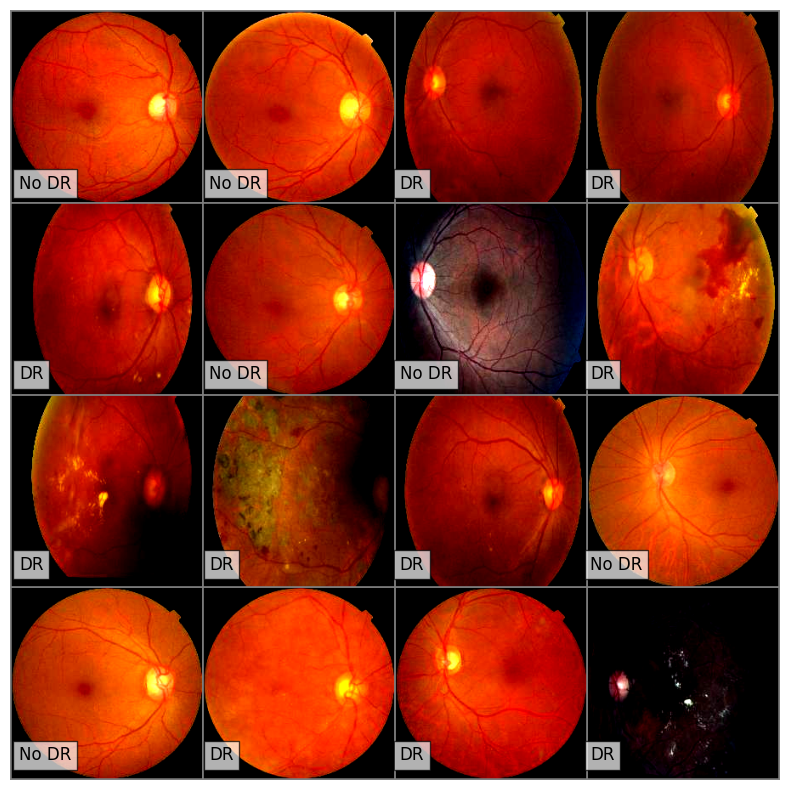

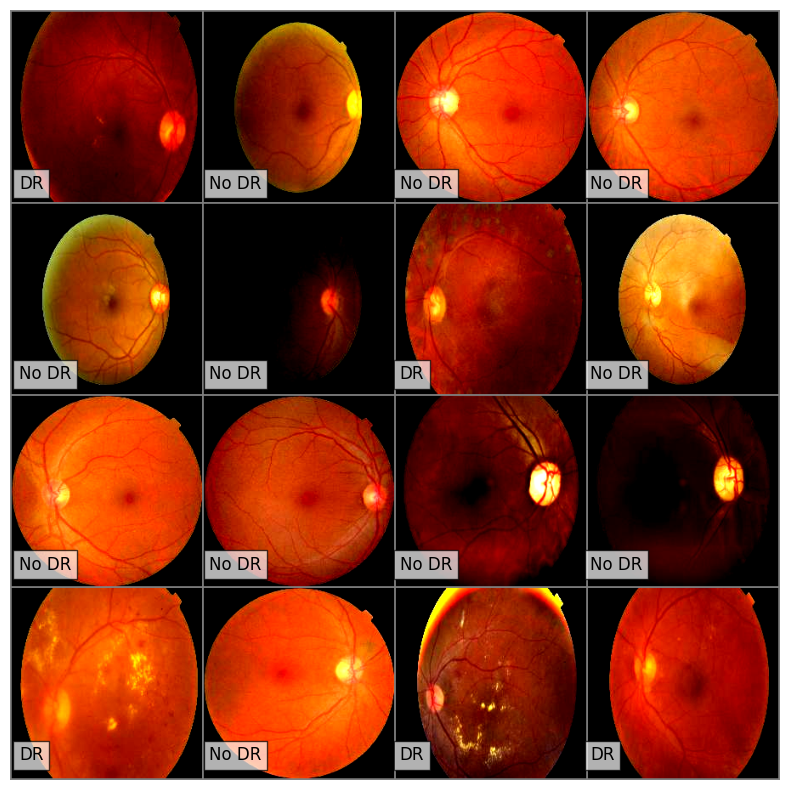

In [10]:
# Function to show images with labels
def imshow_with_labels(imgs, labels, class_names):
    imgs = imgs / 2 + 0.5  # unnormalize
    npimg = imgs.numpy()
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

    for i in range(16):
        row = i // 4
        col = i % 4
        ax.text(
            col * 224 + 10,
            row * 224 + 210,
            class_names[labels[i]],
            bbox=dict(facecolor='white', alpha=0.7),
            fontsize=12, color='black'
        )
    plt.show()

# Display 4x4 images from a dataset with labels
def show_images_grid_with_labels(dataset, class_names):
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)
    images, labels = next(iter(dataloader))
    imshow_with_labels(torchvision.utils.make_grid(images, nrow=4), labels, class_names)

# Show 4x4 images from training data
show_images_grid_with_labels(train_dataset, class_names)

# Show 4x4 images from testing data
show_images_grid_with_labels(test_dataset, class_names)


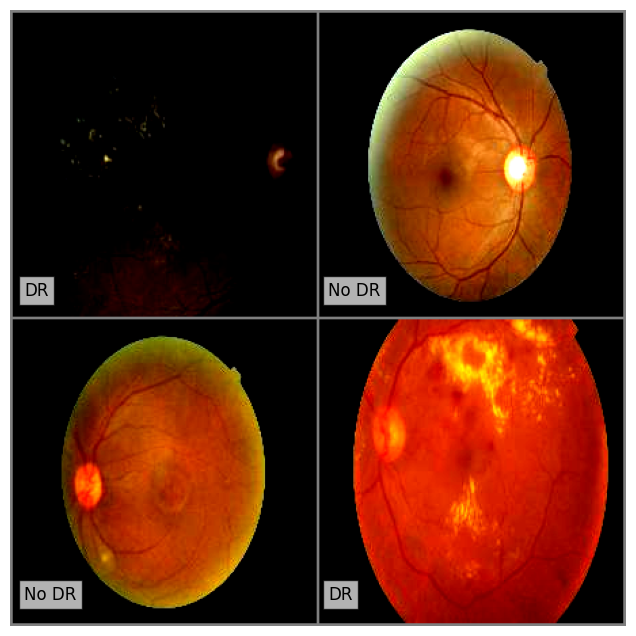

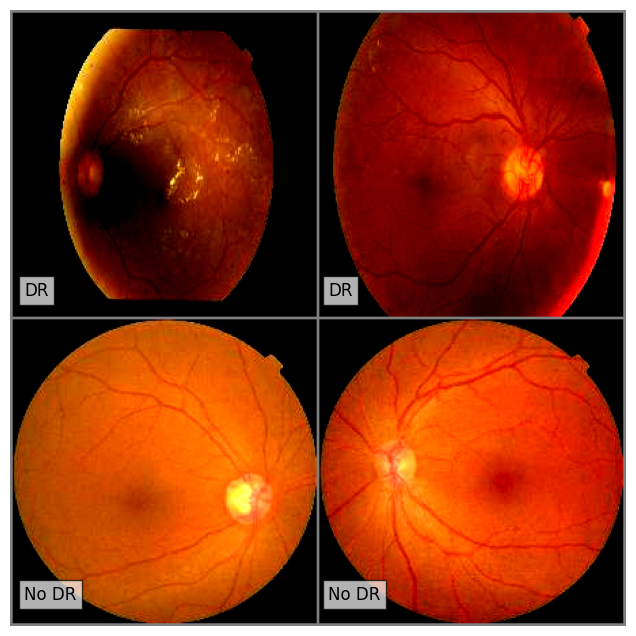

In [11]:
# Function to show images with labels
def imshow_with_labels(imgs, labels, class_names):
    imgs = imgs / 2 + 0.5  # unnormalize
    npimg = imgs.numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

    # Annotate each image with its corresponding label
    for i in range(4):
        row = i // 2
        col = i % 2
        ax.text(
            col * 224 + 10,  # x position
            row * 224 + 210, # y position (near the bottom of the image)
            class_names[labels[i]],
            bbox=dict(facecolor='white', alpha=0.7),
            fontsize=12, color='black'
        )
    plt.show()

# Display 2x2 images from a dataset with labels
def show_images_grid_with_labels(dataset, class_names):
    # Create a DataLoader
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)
    # Get a batch of images
    images, labels = next(iter(dataloader))

    # Display images with labels
    imshow_with_labels(torchvision.utils.make_grid(images, nrow=2), labels, class_names)

# Show 2x2 images from training data
show_images_grid_with_labels(train_dataset, class_names)

# Show 2x2 images from testing data
show_images_grid_with_labels(test_dataset, class_names)


In [12]:
# Load pre-trained ResNet-34 model
resnet34 = models.resnet34(pretrained=True)

# Modify the final layer to output 3 classes
num_features = resnet34.fc.in_features
resnet34.fc = nn.Linear(num_features, 2)

# Move the model to GPU if available
resnet34 = resnet34.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s]


In [13]:
# Define data loaders and batch size
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

In [14]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet34.parameters(), lr=0.0001)
num_epochs = 15

#Training

In [ ]:
# Training loop settings
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

# Function to calculate accuracy
def calculate_accuracy(loader, model, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    average_loss = running_loss / len(loader)
    model.train()  # Set the model back to training mode

    return accuracy, average_loss

for epoch in range(num_epochs):
    resnet34.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Calculate training accuracy and loss
    train_accuracy, train_loss = calculate_accuracy(train_loader, resnet34, device)

    # Calculate testing accuracy and loss
    test_accuracy, test_loss = calculate_accuracy(test_loader, resnet34, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
    print(f"Testing Loss: {test_loss:.4f}, Testing Accuracy: {test_accuracy:.2f}%")

print("Finished Training")
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot training and testing accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.legend()

# Plot training and testing loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()

plt.show()

Epoch [1/15]
Training Loss: 0.0568, Training Accuracy: 97.97%
Testing Loss: 0.0767, Testing Accuracy: 97.54%
Epoch [2/15]
Training Loss: 0.0608, Training Accuracy: 98.77%
Testing Loss: 0.1006, Testing Accuracy: 96.83%
Epoch [3/15]
Training Loss: 0.0078, Training Accuracy: 99.91%
Testing Loss: 0.0549, Testing Accuracy: 97.89%
Epoch [4/15]
Training Loss: 0.0069, Training Accuracy: 99.69%
Testing Loss: 0.0521, Testing Accuracy: 98.42%
Epoch [5/15]
Training Loss: 0.0397, Training Accuracy: 98.85%
Testing Loss: 0.1159, Testing Accuracy: 96.30%
Epoch [6/15]
Training Loss: 0.0059, Training Accuracy: 99.87%
Testing Loss: 0.0519, Testing Accuracy: 98.77%
Epoch [7/15]
Training Loss: 0.0007, Training Accuracy: 100.00%
Testing Loss: 0.0450, Testing Accuracy: 98.59%
Epoch [8/15]
Training Loss: 0.0061, Training Accuracy: 99.82%
Testing Loss: 0.0884, Testing Accuracy: 97.01%
Epoch [9/15]
Training Loss: 0.1208, Training Accuracy: 97.97%
Testing Loss: 0.1638, Testing Accuracy: 97.71%
Epoch [10/15]
Trai

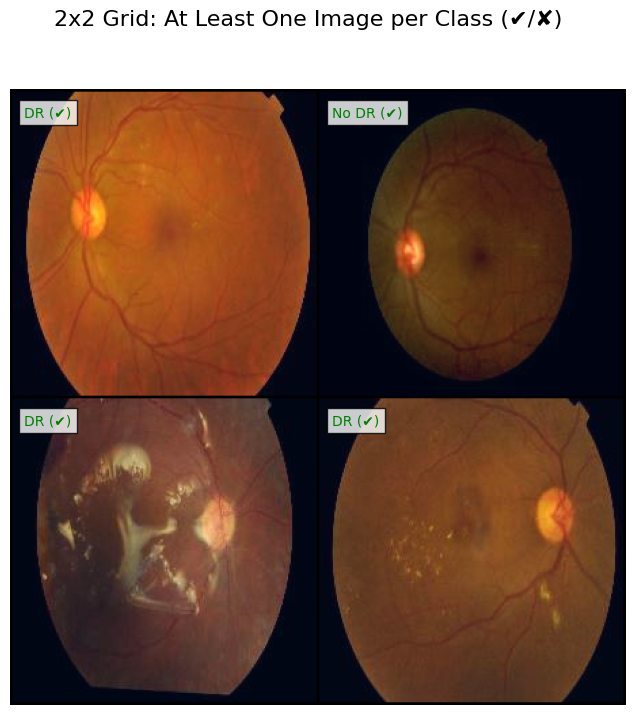

In [ ]:
import random

# Function to display at least one image of each class in a 2x2 grid
def show_at_least_one_per_class_2x2(test_loader, class_names, model, device):
    n_classes = len(class_names)
    model.eval()  # Set model to evaluation mode

    class_images = [None] * n_classes  # Placeholder for one image per class
    additional_images = []  # Extra images to fill the grid

    # Collect images for each class
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        for img, label, pred in zip(images, labels, predictions):
            class_idx = label.item()
            if class_images[class_idx] is None:  # Select one image per class
                class_images[class_idx] = (img.cpu(), label.cpu(), pred.cpu())
            else:
                additional_images.append((img.cpu(), label.cpu(), pred.cpu()))

        if all(img is not None for img in class_images):
            break

    # Select up to 4 unique classes and fill the remaining slots randomly
    selected_images = [img for img in class_images if img is not None][:4]
    while len(selected_images) < 4:
        selected_images.append(random.choice(additional_images))

    # Prepare the 4 images, labels, and predictions
    imgs = torch.stack([img for img, _, _ in selected_images])
    labels = [label.item() for _, label, _ in selected_images]
    predictions = [pred.item() for _, _, pred in selected_images]

    # Create a 2x2 grid
    grid_img = torchvision.utils.make_grid(imgs, nrow=2, normalize=True, scale_each=True)

    # Display the grid with annotations
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
    plt.axis('off')

    for i, (label, prediction) in enumerate(zip(labels, predictions)):
        correct = "✔" if label == prediction else "✘"
        color = 'green' if label == prediction else 'red'
        plt.text(
            (i % 2) * (grid_img.size(2) / 2) + 10,  # x position
            (i // 2) * (grid_img.size(1) / 2) + 20, # y position
            f"{class_names[label]} ({correct})",
            bbox=dict(facecolor='white', alpha=0.8),
            fontsize=10, color=color
        )

    plt.suptitle("2x2 Grid: At Least One Image per Class (✔/✘)", fontsize=16)
    plt.show()

# Example usage
show_at_least_one_per_class_2x2(test_loader, class_names, resnet34, device)


#Model Saving

In [ ]:
# Save the model
model_save_path = "/content/drive/MyDrive/Diagnosis of Diabetic Retinopathy/resnet34_model.pth"
torch.save(resnet34.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/Diagnosis of Diabetic Retinopathy/resnet34_model.pth


# Training Confusion Matrix and Testing Confusion Matrix

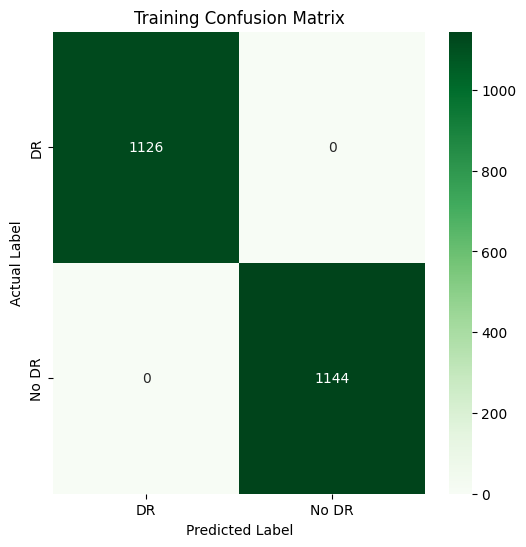

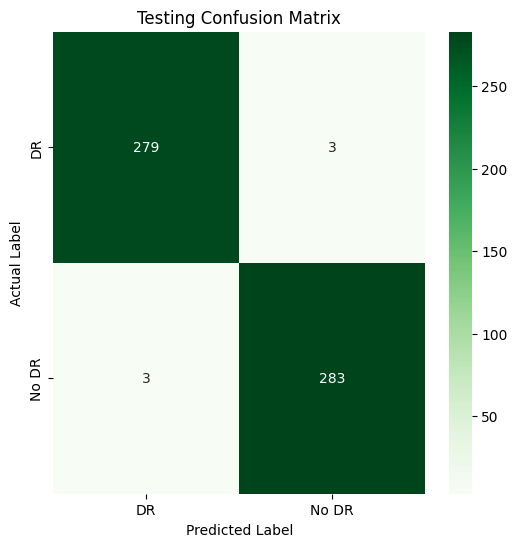

In [ ]:
# Confusion Matrix
def calculate_confusion_matrix(loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return confusion_matrix(all_labels, all_preds)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Calculate confusion matrices
train_cm = calculate_confusion_matrix(train_loader, resnet34, device)
test_cm = calculate_confusion_matrix(test_loader, resnet34, device)

# Plot confusion matrices
plot_confusion_matrix(train_cm, class_names, title='Training Confusion Matrix')
plot_confusion_matrix(test_cm, class_names, title='Testing Confusion Matrix')

#ROC CURVE

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


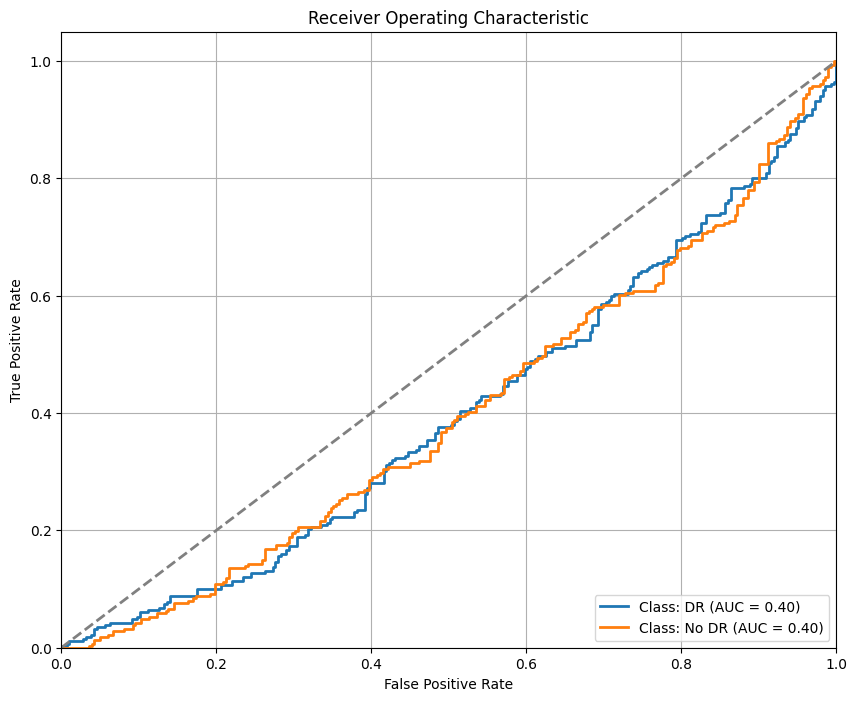

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load ResNet-34 model
resnet34 = models.resnet34(pretrained=True)
num_classes = len(class_names)  # Get the number of classes

# Modify the final layer to match the number of output classes
resnet34.fc = nn.Linear(resnet34.fc.in_features, num_classes)
resnet34 = resnet34.to(device)  # Move model to GPU or CPU

# Function to calculate ROC curve for multi-class
def calculate_roc_curve(loader, model, device, num_classes):
    all_labels = []
    all_probs = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Get probabilities for all classes
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels, [row[i] for row in all_probs], pos_label=i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    return fpr, tpr, roc_auc

# Function to plot ROC curve for multi-class with class names
def plot_roc_curve(fpr, tpr, roc_auc, num_classes, class_names, title='Receiver Operating Characteristic'):
    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Class: {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal reference line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Calculate ROC curve and AUC for each class using ResNet-34
fpr, tpr, roc_auc = calculate_roc_curve(test_loader, resnet34, device, num_classes)

# Plot ROC curve for each class with class names
plot_roc_curve(fpr, tpr, roc_auc, num_classes, class_names)


#Grad-CAM (Gradient-weighted Class Activation Mapping)

In [ ]:
def apply_gradcam(model, image, target_class, device):
    def hook_fn(module, input, output):
        global feature_map
        feature_map = output

    # Register hook on the last convolutional layer
    model.layer4[1].register_forward_hook(hook_fn)

    # Ensure the image is sent to the correct device
    image = image.unsqueeze(0).to(device)

    # Put the model in evaluation mode
    model.eval()

    # Forward pass
    output = model(image)

    # Backward pass for the target class, retain the computation graph
    output[:, target_class].backward(retain_graph=True)

    # Compute gradients for the feature map
    gradients = torch.autograd.grad(outputs=output[:, target_class], inputs=feature_map)[0]
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # Weight the feature map by the gradients
    for i in range(feature_map.shape[1]):
        feature_map[:, i, :, :] *= pooled_gradients[i]

    # Create a heatmap by averaging the weighted feature map across all channels
    heatmap = torch.mean(feature_map, dim=1).squeeze()
    heatmap = torch.relu(heatmap)

    return heatmap


In [ ]:
def show_gradcam(model, image, target_class, class_names, device):
    # Ensure the image tensor is on the correct device
    image = image.to(device)

    # Apply Grad-CAM
    heatmap = apply_gradcam(model, image, target_class, device)

    # Undo normalization (reverse the transformation applied during preprocessing)
    # Mean and std values used in preprocessing
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)

    # Revert the normalization (i.e., multiply by std and add mean)
    image = image * std[:, None, None] + mean[:, None, None]

    # Convert the image from tensor to numpy array and move it to CPU
    img = image.cpu().detach().numpy().transpose((1, 2, 0))  # Move to CPU and convert
    img = np.clip(img, 0, 1)  # Ensure the image is in [0, 1] range

    # Convert heatmap from tensor to numpy array and move to CPU
    heatmap = heatmap.cpu().detach().numpy()

    # Normalize heatmap to [0, 1]
    heatmap = np.maximum(heatmap, 0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))  # Resize to match image size

    # Apply colormap to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    # Combine image and heatmap
    combined = np.float32(img) + heatmap
    combined = np.clip(combined, 0, 1)  # Ensure the pixel values are within [0, 1]

    # Display the image and heatmap together
    plt.imshow(combined)
    plt.title(f"Grad-CAM for {class_names[target_class]}")
    plt.show()


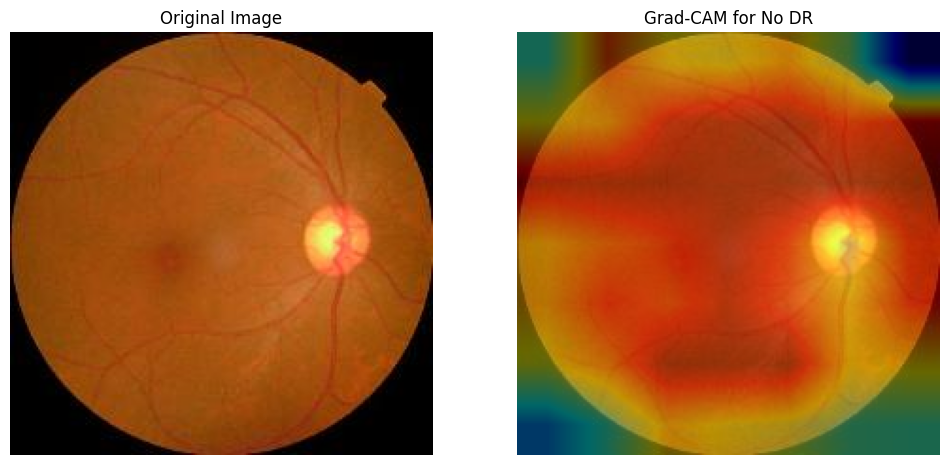

In [ ]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import random

# Corrected show_gradcam function with original image display
def show_gradcam(model, image, target_class, class_names, device):
    # Ensure the image tensor is on the correct device
    image = image.to(device)

    # Apply Grad-CAM (assuming the function `apply_gradcam` is defined)
    heatmap = apply_gradcam(model, image, target_class, device)

    # Undo normalization (reverse the transformation applied during preprocessing)
    # Mean and std values used in preprocessing
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)

    # Revert the normalization (i.e., multiply by std and add mean)
    image = image * std[:, None, None] + mean[:, None, None]

    # Convert the image from tensor to numpy array and move it to CPU
    img = image.cpu().detach().numpy().transpose((1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    img = np.clip(img, 0, 1)  # Ensure the image is in [0, 1] range

    # Convert heatmap from tensor to numpy array and move to CPU
    heatmap = heatmap.cpu().detach().numpy()

    # Normalize heatmap to [0, 1]
    heatmap = np.maximum(heatmap, 0)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))  # Resize to match image size

    # Apply colormap to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    # Combine image and heatmap
    combined = np.float32(img) * 0.6 + heatmap * 0.4  # Adjust blend ratio (0.6 for image, 0.4 for heatmap)
    combined = np.clip(combined, 0, 1)  # Ensure the pixel values are within [0, 1]

    # Plot the original image and the Grad-CAM visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Display the original image
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')  # Hide axes for clarity

    # Display the Grad-CAM image
    axes[1].imshow(combined)
    axes[1].set_title(f"Grad-CAM for {class_names[target_class]}")
    axes[1].axis('off')  # Hide axes for clarity

    plt.show()

# Example usage
random_idx = random.randint(11, len(test_dataset) - 1)
test_image, test_label = test_dataset[random_idx]

# Show Grad-CAM visualization with original image
show_gradcam(resnet34, test_image, test_label, class_names, device)
